# 06 — Integrated monthly feature engineering
**Purpose:** create monthly Sentinel-2 metrics and merge optical, comparable-track SAR, and ERA5-Land features without filling missing observations.  
**Inputs:** Earth Engine project ID plus Phase 4 climate and Phase 5 SAR CSV files.  
**Outputs:** monthly Sentinel-2 CSV, integrated monthly feature CSV, and availability chart.  
**Runtime:** first monthly Sentinel-2 extraction may take 10–30 minutes; cached reruns are fast.  
**Dependencies:** completed notebooks 04 and 05, authenticated Earth Engine, and a registered Cloud project.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/langtang-glacier-ai'
%pip -q install -r requirements.txt


Mounted at /content/drive
/content/drive/MyDrive/langtang-glacier-ai
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.6 MB/s eta 0:00:00


In [2]:
import os
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import ee
import pandas as pd
from src.config import SETTINGS
from src.feature_engineering import build_integrated_monthly_features
from src.gee_utils import build_rois, initialize_earth_engine
from src.glacier_features import extract_monthly_snow_dataframe_sequential
from src.utils import ensure_output_directories
from src.visualization import plot_feature_availability
ensure_output_directories()


In [3]:
EE_PROJECT = os.environ.get('EE_PROJECT') or input('Earth Engine Cloud project ID: ').strip()
if not EE_PROJECT:
    raise ValueError('An Earth Engine-enabled Google Cloud project ID is required.')
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    initialize_earth_engine(project=EE_PROJECT, authenticate=True)
print('Earth Engine initialized with:', EE_PROJECT)


Earth Engine Cloud project ID: my-youtube-api-keys-453716
Earth Engine initialized with: my-youtube-api-keys-453716


## Monthly Sentinel-2 snow/NDSI metrics
Cloudy and empty months remain missing. `snow_fraction` is the NDSI/brightness proxy over valid pixels inside the GLIMS ROI, not total glacier area. Set `FORCE_REFRESH_OPTICAL=True` only after changing source imagery or thresholds.

In [4]:
rois = build_rois()
optical_path = SETTINGS.output_tables / 'sentinel2_monthly_snow_metrics.csv'
FORCE_REFRESH_OPTICAL = False
if optical_path.exists() and not FORCE_REFRESH_OPTICAL:
    optical_monthly = pd.read_csv(optical_path, parse_dates=['date'])
    print(f'Loaded {len(optical_monthly)} cached optical months')
else:
    optical_monthly = extract_monthly_snow_dataframe_sequential(
        rois['glacier_roi'],
        checkpoint_path=str(optical_path),
        resume=not FORCE_REFRESH_OPTICAL,
    )
    print('Saved:', optical_path)
display(optical_monthly.tail(18))


Sentinel-2 monthly reduction complete: 2017-04-01
Sentinel-2 monthly reduction complete: 2017-05-01
Sentinel-2 monthly reduction complete: 2017-06-01
Sentinel-2 monthly reduction complete: 2017-07-01
Sentinel-2 monthly reduction complete: 2017-08-01
Sentinel-2 monthly reduction complete: 2017-09-01
Sentinel-2 monthly reduction complete: 2017-10-01
Sentinel-2 monthly reduction complete: 2017-11-01
Sentinel-2 monthly reduction complete: 2017-12-01
Sentinel-2 monthly reduction complete: 2018-01-01
Sentinel-2 monthly reduction complete: 2018-02-01
Sentinel-2 monthly reduction complete: 2018-03-01
Sentinel-2 monthly reduction complete: 2018-04-01
Sentinel-2 monthly reduction complete: 2018-05-01
Sentinel-2 monthly reduction complete: 2018-06-01
Sentinel-2 monthly reduction complete: 2018-07-01
Sentinel-2 monthly reduction complete: 2018-08-01
Sentinel-2 monthly reduction complete: 2018-09-01
Sentinel-2 monthly reduction complete: 2018-10-01
Sentinel-2 monthly reduction complete: 2018-11-01


,date,mean_valid_observation_count,missing_data_flag,ndsi_mean,scene_count,snow_area_km2,snow_fraction_valid,valid_area_fraction,observation_count,expected_observation_count,period_completeness,is_complete_period,quality_status,quality_reason
95,2025-03-01,11.064083,0,0.582733,14,3.933043,0.754805,0.998432,11.064083,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
96,2025-04-01,9.805004,0,0.346980,14,2.642883,0.507206,0.998432,9.805004,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
97,2025-05-01,3.723155,0,0.304244,14,2.150168,0.445321,0.925176,3.723155,<NA>,0.925176,True,GOOD,valid-area fraction is at least 0.80
98,2025-06-01,3.583875,0,0.466424,8,3.100437,0.595017,0.998432,3.583875,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
99,2025-07-01,2.625037,0,0.283863,10,2.038550,0.391226,0.998432,2.625037,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
100,2025-08-01,1.339998,0,0.339814,8,1.045084,0.497648,0.402396,1.339998,<NA>,0.402396,False,INSUFFICIENT,valid-area fraction is below 0.80
101,2025-09-01,2.700996,0,0.292285,11,1.969977,0.386534,0.976559,2.700996,<NA>,0.976559,True,GOOD,valid-area fraction is at least 0.80
102,2025-10-01,9.633438,0,0.407997,13,2.874504,0.551657,0.998432,9.633438,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
103,2025-11-01,12.165909,0,0.560828,14,3.604272,0.691710,0.998432,12.165909,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80
104,2025-12-01,14.728095,0,0.382768,15,2.783508,0.534194,0.998432,14.728095,<NA>,0.998432,True,GOOD,valid-area fraction is at least 0.80


## Merge the three real data sources
The notebook requires outputs from notebooks 04 and 05. It raises a clear error if either file is absent. Values are joined by calendar month; large gaps are never interpolated.

In [5]:
climate_path = SETTINGS.output_tables / 'era5_land_monthly_climate.csv'
sar_path = SETTINGS.output_tables / 'sentinel1_monthly_sar_metrics.csv'
integrated = build_integrated_monthly_features(
    climate_path=climate_path, optical_path=optical_path, sar_path=sar_path
)
feature_path = SETTINGS.output_tables / 'langtang_monthly_features.csv'
integrated.to_csv(feature_path, index=False)
print('Saved:', feature_path)
print('Shape:', integrated.shape)
display(integrated.tail(18))


Saved: /content/drive/MyDrive/langtang-glacier-ai/outputs/tables/langtang_monthly_features.csv
Shape: (134, 56)


,date,temp_mean,temp_max,temp_min,temp_anomaly,precip_1d_max,precip_3d_max,precip_7d_max,precip_30d_max,precip_month,...,climate_expected_observation_count,climate_period_completeness,climate_is_complete_period,climate_quality_status,climate_quality_reason,sentinel1_expected_observation_count,sentinel1_period_completeness,sentinel1_is_complete_period,sentinel1_quality_status,sentinel1_quality_reason
116,2025-03-01,-5.927125,4.124642,-17.579670,0.558191,9.580936,29.869582,35.305724,89.935600,47.552459,...,31,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955847,True,GOOD,VV/VH and ROI coverage pass requirements
117,2025-04-01,-1.665825,5.789748,-11.805456,1.275408,10.628366,22.425798,33.170289,79.250688,79.250688,...,30,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955847,True,GOOD,VV/VH and ROI coverage pass requirements
118,2025-05-01,2.674047,10.148621,-8.668634,1.416435,19.220914,30.404806,54.660077,157.352141,160.511544,...,31,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955847,True,GOOD,VV/VH and ROI coverage pass requirements
119,2025-06-01,5.938024,13.088634,-4.843439,0.385120,27.030255,72.423812,141.561713,381.251352,381.251352,...,30,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955728,True,GOOD,VV/VH and ROI coverage pass requirements
120,2025-07-01,7.955694,12.697812,3.997629,0.768242,32.238669,66.264496,118.606355,452.870285,411.318060,...,31,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955728,True,GOOD,VV/VH and ROI coverage pass requirements
121,2025-08-01,7.566875,12.436501,4.462229,0.609156,32.478017,63.405191,118.513899,433.443359,424.106011,...,31,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955847,True,GOOD,VV/VH and ROI coverage pass requirements
122,2025-09-01,6.263319,11.006812,2.027688,1.233182,14.763077,41.668564,107.639790,412.511643,259.508014,...,30,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955847,True,GOOD,VV/VH and ROI coverage pass requirements
123,2025-10-01,0.370723,6.678553,-10.057018,0.361146,70.022087,112.228241,161.687011,365.980025,236.403465,...,31,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955847,True,GOOD,VV/VH and ROI coverage pass requirements
124,2025-11-01,-4.169219,2.976036,-12.132678,-0.173294,9.449699,64.904056,99.680438,203.820176,25.125000,...,30,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955847,True,GOOD,VV/VH and ROI coverage pass requirements
125,2025-12-01,-5.051657,3.333933,-14.831047,1.687053,0.520470,0.672726,0.843051,15.689776,1.628558,...,31,1.000000,True,GOOD,coverage and completeness requirements passed,NaN,0.955847,True,GOOD,VV/VH and ROI coverage pass requirements


,missing_percent
climate_missing_data_flag,0.746269
sentinel2_missing_data_flag,22.388060
sentinel1_missing_data_flag,13.432836


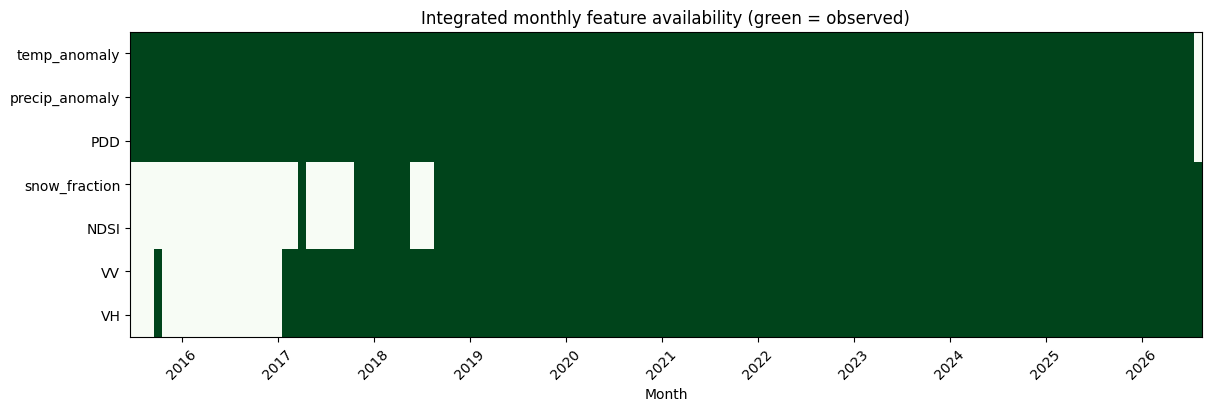

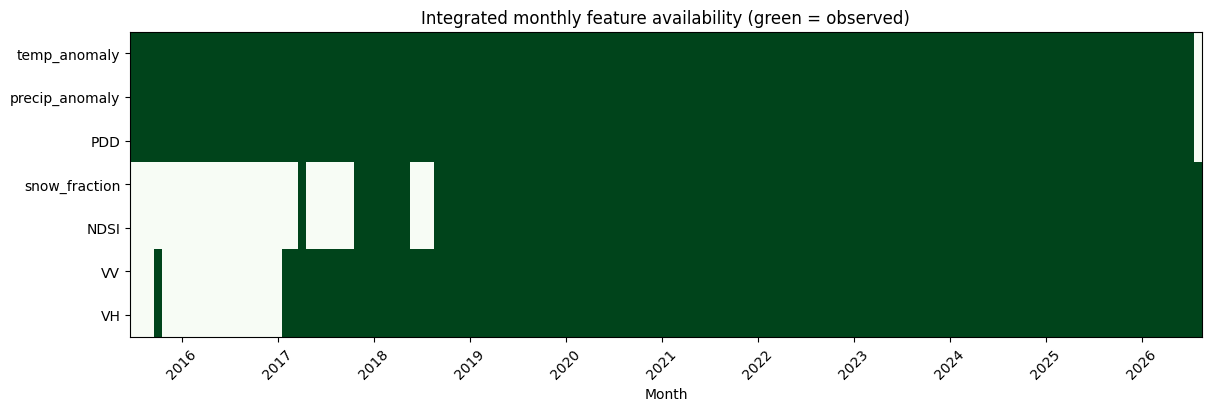

In [6]:
quality_columns = [
    'climate_missing_data_flag', 'sentinel2_missing_data_flag',
    'sentinel1_missing_data_flag',
]
quality_summary = integrated[quality_columns].mean().mul(100).rename('missing_percent')
display(quality_summary.to_frame())
availability_figure = plot_feature_availability(
    integrated, SETTINGS.output_charts / 'integrated_feature_availability.png'
)
availability_figure


## Interpretation checkpoint
Green availability cells show observed features, not necessarily high-quality observations; inspect the source-specific coverage and scene-count columns. Monthly optical anomalies require at least three historical observations for the same calendar month. `snow_fraction_change` is missing when either adjacent month lacks optical data. Do not impute these gaps before trend/anomaly work without a documented method and sensitivity analysis. The integrated table contains no collapse label and no anomaly score yet.